Public Transit (BRT & Buses via GTFS)


In [ ]:
import pandas as pd
import os
import networkx as nx

# Set your GTFS path
gtfs_path = r"C:\Users\kejsi\Downloads\gtfs_rio-de-janeiro"

#  Load GTFS data
stops = pd.read_csv(os.path.join(gtfs_path, "stops.txt"))
routes = pd.read_csv(os.path.join(gtfs_path, "routes.txt"))
trips = pd.read_csv(os.path.join(gtfs_path, "trips.txt"))
stop_times = pd.read_csv(os.path.join(gtfs_path, "stop_times.txt"), low_memory=False)

#  Step 2: Handle Missing Data

#  Fix missing stop_headsign using trip_headsign from trips.txt
stop_times['arrival_time'] = pd.to_timedelta(stop_times['arrival_time'].astype(str), errors='coerce')
stop_times['departure_time'] = pd.to_timedelta(stop_times['departure_time'].astype(str), errors='coerce')


#  Drop columns that are mostly missing and not critical
stops.drop(columns=['parent_station', 'stop_timezone', 'zone_id', 'stop_url'], inplace=True)

#  Step 3: Verify Travel Times

#  Convert time columns to timedelta format to handle after-midnight times
stop_times['arrival_time'] = pd.to_timedelta(stop_times['arrival_time'].astype(str))
stop_times['departure_time'] = pd.to_timedelta(stop_times['departure_time'].astype(str))


#  Ensure stops are sorted by stop_sequence before calculating travel time
stop_times.sort_values(by=['trip_id', 'stop_sequence'], inplace=True)

#  Calculate travel time in minutes
stop_times['travel_time'] = stop_times.groupby('trip_id')['arrival_time'].diff().dt.total_seconds() / 60  

#  Find negative travel times
negative_travel_times = stop_times[stop_times['travel_time'] < 0]
print("Negative Travel Times Found:\n", negative_travel_times)

#  Step 4: Check for Missing GTFS Schedule Data

#  Check if frequencies.txt exists and integrate if needed
freq_path = os.path.join(gtfs_path, "frequencies.txt")
if os.path.exists(freq_path):
    frequencies = pd.read_csv(freq_path)
    print("Frequencies data detected. You may need to compute synthetic stop times.")

#  Step 5: Construct Transit Network Graph

G_transit = nx.DiGraph()

# When adding GTFS stops as nodes:
for _, row in stops.iterrows():
    G_transit.add_node(
        row['stop_id'], 
        name=row['stop_name'], 
        pos=(row['stop_lat'], row['stop_lon'])
    )


#  Add edges (routes)
prev_row = None
for _, row in stop_times.iterrows():
    if prev_row is not None and row['trip_id'] == prev_row['trip_id']:
        if pd.notnull(row['travel_time']):
            G_transit.add_edge(prev_row['stop_id'], row['stop_id'], travel_time=row['travel_time'], mode='bus')
    prev_row = row


#  Save cleaned data for next steps
stops.to_csv(os.path.join(gtfs_path, "stops_cleaned.csv"), index=False)
stop_times.to_csv(os.path.join(gtfs_path, "stop_times_cleaned.csv"), index=False)

print("GTFS Cleaning Complete! Data saved.")



Negative Travel Times Found:
 Empty DataFrame
Columns: [trip_id, stop_sequence, stop_id, arrival_time, departure_time, stop_headsign, shape_dist_traveled, timepoint, travel_time]
Index: []
Frequencies data detected. You may need to compute synthetic stop times.
GTFS Cleaning Complete! Data saved.


Subway & Tram (VLT)


In [ ]:
import geopandas as gpd  
import networkx as nx
from shapely.geometry import MultiLineString, LineString, Point
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# ------------------------------
# 1. Load data and enforce CRS
# ------------------------------
def enforce_crs(gdf):
    if gdf.crs != "EPSG:4326":
        return gdf.to_crs("EPSG:4326")
    return gdf

subway_routes = enforce_crs(gpd.read_file("C://Users//kejsi//Downloads//Trajetos_Metro.geojson"))
subway_stations = enforce_crs(gpd.read_file("C://Users//kejsi//Downloads//Estacoes_Metro.geojson"))
vlt_routes = enforce_crs(gpd.read_file("C://Users//kejsi//Downloads//Trajeto_VLT.geojson"))
vlt_stations = enforce_crs(gpd.read_file("C://Users//kejsi//Downloads//Estacoes_VLT.geojson"))

# ------------------------------
# 2. Create directed graph and add stations
# ------------------------------
G = nx.DiGraph()

def add_stations(df, system):
    for _, row in df.iterrows():
        station_id = f"{system}_{row['nome']}"
        G.add_node(
            station_id,
            pos=(row.geometry.y, row.geometry.x),
            name=row["nome"],
            system=system
        )

add_stations(subway_stations, "subway")
add_stations(vlt_stations, "vlt")

# ------------------------------
# 3. Build spatial index for station snapping
# ------------------------------
all_stations = []
for system_df, system in [(subway_stations, "subway"), (vlt_stations, "vlt")]:
    for _, row in system_df.iterrows():
        geom = row.geometry
        station_id = f"{system}_{row['nome']}"
        all_stations.append((station_id, geom))

station_points = gpd.GeoSeries([geom for _, geom in all_stations], crs="EPSG:4326")
station_points_proj = station_points.to_crs(epsg=3857)  #  Precompute once
station_ids_list = [sid for sid, _ in all_stations]

# Spatial snapping: find nearest station within X meters
def find_nearest_station(coord, threshold_m=220):
    point_wgs = Point(coord[1], coord[0])
    point_gdf = gpd.GeoSeries([point_wgs], crs="EPSG:4326")
    point_proj = point_gdf.to_crs(epsg=3857).iloc[0]

    distances = station_points_proj.distance(point_proj)
    min_idx = distances.idxmin()
    if distances[min_idx] < threshold_m:
        return station_ids_list[min_idx]
    return None

# ------------------------------
# 4. Estimate travel time between two coordinates
# ------------------------------
def estimate_time(coord1, coord2, avg_speed_km_h):
    dist_km = geodesic(coord1, coord2).km
    return dist_km / (avg_speed_km_h / 60)

# ------------------------------
# 5. Add route edges between snapped stations
# ------------------------------
def add_routes(df, system, avg_speed_km_h):
    for _, row in df.iterrows():
        geometry = row.geometry
        lines = geometry.geoms if isinstance(geometry, MultiLineString) else [geometry]

        for line in lines:
            coords = list(line.coords)
            snapped_nodes = []

            for coord in coords:
                latlon = (coord[1], coord[0])
                node = find_nearest_station(latlon)
                if node:
                    if not snapped_nodes or snapped_nodes[-1] != node:
                        snapped_nodes.append(node)

            for i in range(len(snapped_nodes) - 1):
                node1 = snapped_nodes[i]
                node2 = snapped_nodes[i + 1]
                if node1 != node2:
                    coord1 = G.nodes[node1]['pos']
                    coord2 = G.nodes[node2]['pos']
                    travel_time = estimate_time(coord1, coord2, avg_speed_km_h)
                    G.add_edge(node1, node2, system=system, travel_time=travel_time, mode=system)
                    G.add_edge(node2, node1, system=system, travel_time=travel_time, mode=system)

add_routes(subway_routes, "subway", avg_speed_km_h=35)
add_routes(vlt_routes, "vlt", avg_speed_km_h=20)

# ------------------------------
# 6. Add intermodal transfers (subway ↔ VLT) —  Optimized
# ------------------------------
# Use spatial join instead of nested loops
buffer_deg = 50 / 111000  # ~50m in degrees
# Reproject to metric CRS before buffering
subway_buff = subway_stations.to_crs(epsg=3857).copy()
subway_buff["geometry"] = subway_buff.geometry.buffer(50)  # buffer in meters

# Reproject VLT stations too for spatial join
vlt_stations_proj = vlt_stations.to_crs(epsg=3857)

# Perform spatial join in projected CRS
joined = gpd.sjoin(subway_buff, vlt_stations_proj, how="inner", predicate="intersects")

# Use original names from projected GeoDataFrames
for _, row in joined.iterrows():
    id_subway = f"subway_{row['nome_left']}"
    id_vlt = f"vlt_{row['nome_right']}"
    G.add_edge(id_subway, id_vlt, travel_time=2, mode="transfer")
    G.add_edge(id_vlt, id_subway, travel_time=2, mode="transfer")


# Add manual fallback for Carioca if not picked up automatically
G.add_edge("subway_Carioca", "vlt_Carioca", travel_time=2, mode="transfer")
G.add_edge("vlt_Carioca", "subway_Carioca", travel_time=2, mode="transfer")

# ------------------------------
# 7. Report results
# ------------------------------
print("Graph successfully created with", G.number_of_nodes(), "stations and", G.number_of_edges(), "routes.")

isolated = [n for n in G.nodes if G.degree(n) == 0]
print(f"{len(isolated)} isolated stations out of {G.number_of_nodes()}.")


Graph successfully created with 72 stations and 158 routes.
0 isolated stations out of 72.


In [ ]:
import matplotlib.pyplot as plt

pos = {node: G.nodes[node]['pos'] for node in G.nodes}
nx.draw(G, pos, node_size=20, with_labels=False, arrows=True)
plt.show()


Main polygon has 27723 coordinates.
Number of holes: 139


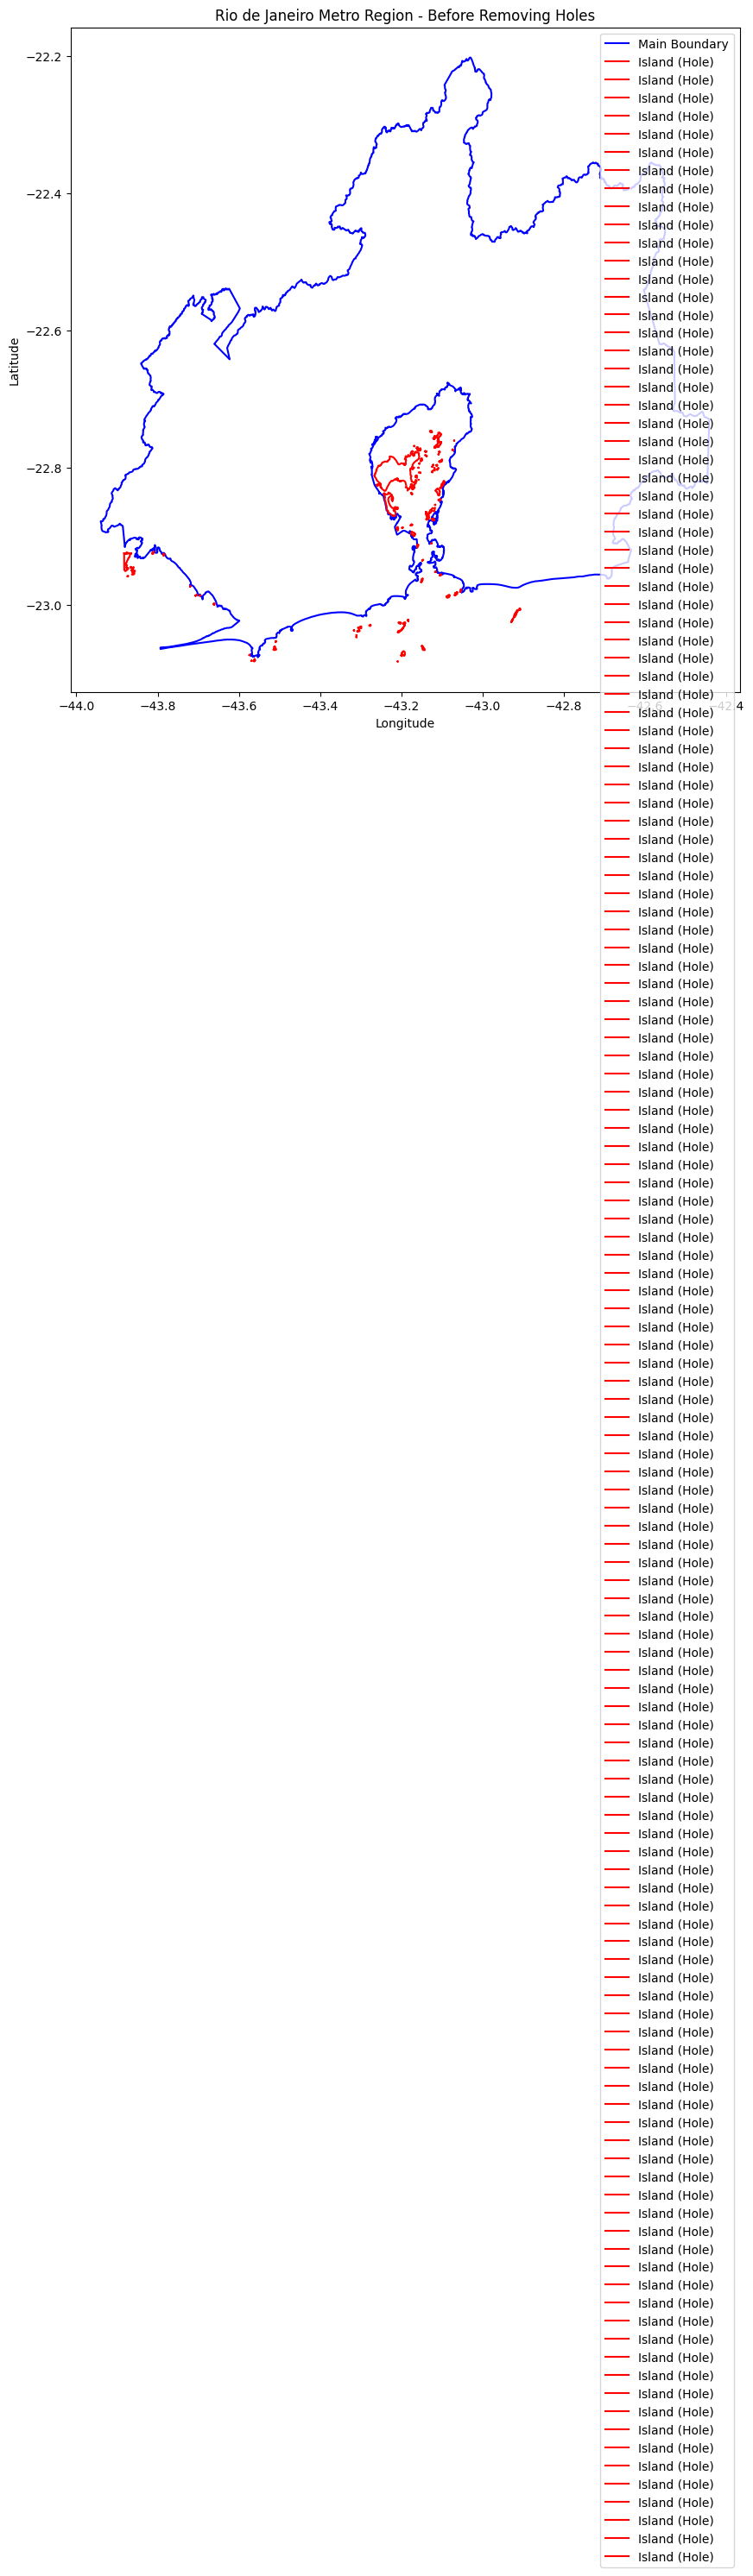

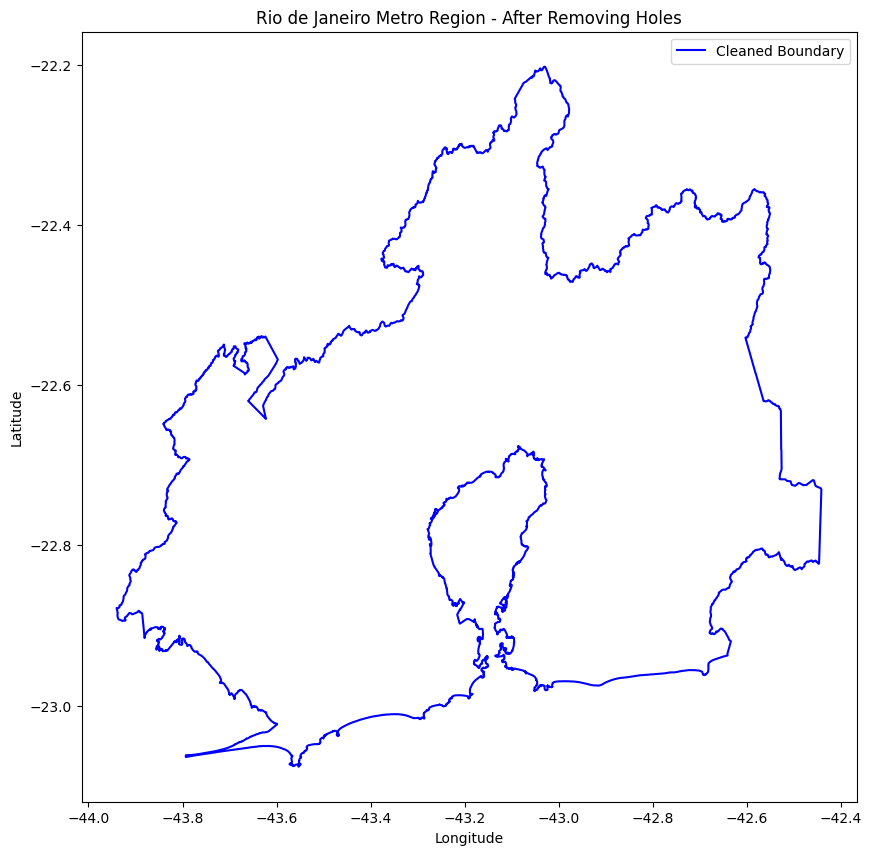

In [ ]:
import json
import matplotlib.pyplot as plt
from shapely.geometry import Polygon, MultiPolygon, shape
from shapely.validation import make_valid
import osmnx as ox
import geopandas as gpd
import re

# Define the .poly file path
poly_file = r"\\wsl$\Ubuntu\home\kejsi\rio-metro-region.poly"

# Read the .poly file
with open(poly_file, "r", encoding="utf-8") as f:
    lines = f.readlines()[1:]  # Skip only the header, not the start of polygon data


# Parse the poly file into main polygon and islands
coordinates = []
holes = []
current_poly = []
inside_polygon = False

for line in lines:
    line = line.strip()
    if line == "END":
        if current_poly:
            if not coordinates:
                coordinates = current_poly  # First polygon
            else:
                holes.append(current_poly)  # Remaining are holes
        inside_polygon = False
        current_poly = []
        continue
    if re.match(r"area_\d+:\d+", line):  # Start of a new ring like 'area_1:1'
        inside_polygon = True
        continue
    if inside_polygon:
        lon, lat = map(float, line.split())
        current_poly.append((lon, lat))

#  Add this check here
if not coordinates:
    raise ValueError("No coordinates parsed from the .poly file. Check file structure.")

print(f"Main polygon has {len(coordinates)} coordinates.")
print(f"Number of holes: {len(holes)}")

# Ensure the polygons are closed
if coordinates and coordinates[0] != coordinates[-1]:  
    coordinates.append(coordinates[0])  
for hole in holes:
    if hole[0] != hole[-1]:
        hole.append(hole[0])

# Create the Polygon/MultiPolygon object
main_polygon = Polygon(coordinates, holes)
boundary_shape = MultiPolygon([main_polygon])

# Visualization BEFORE removing holes
fig, ax = plt.subplots(figsize=(10, 10))
for geom in boundary_shape.geoms:  # Loop through MultiPolygon elements
    x, y = geom.exterior.xy
    ax.plot(x, y, 'b-', label="Main Boundary")

    for interior in geom.interiors:  # Plot islands (holes)
        x, y = interior.xy
        ax.plot(x, y, 'r-', label="Island (Hole)")

ax.set_title("Rio de Janeiro Metro Region - Before Removing Holes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()

# REMOVE HOLES: Keep only the main landmass
if boundary_shape.geom_type == "MultiPolygon":
    boundary_shape = max(boundary_shape.geoms, key=lambda p: p.area)  # Keep largest polygon

boundary_shape = Polygon(boundary_shape.exterior)  # Remove holes

# Visualization AFTER removing holes
fig, ax = plt.subplots(figsize=(10, 10))
x, y = boundary_shape.exterior.xy
ax.plot(x, y, 'b-', label="Cleaned Boundary")

ax.set_title("Rio de Janeiro Metro Region - After Removing Holes")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()




In [ ]:
# Ensure geometry is valid
boundary_shape = make_valid(boundary_shape)
if not boundary_shape.is_valid:
    boundary_shape = boundary_shape.buffer(0)  # Last resort fix

# Convert to GeoJSON format (no holes)
geojson_data = {
    "type": "Feature",
    "properties": {},
    "geometry": {
        "type": "Polygon",
        "coordinates": [[list(coord) for coord in boundary_shape.exterior.coords]],
    },
}

# Save as GeoJSON
geojson_file = "rio-metro-region.geojson"
with open(geojson_file, "w", encoding="utf-8") as f:
    json.dump(geojson_data, f, indent=4)

print(f"Conversion successful! GeoJSON saved as {geojson_file}")

# Load boundary as a GeoDataFrame
boundary = gpd.read_file(geojson_file)
if boundary.crs is None or boundary.crs.to_string() != 'EPSG:4326':
    boundary = boundary.set_crs('EPSG:4326')

# Extract road network using the cleaned boundary
G_drive = ox.graph_from_polygon(boundary_shape, network_type="drive")
G_walk = ox.graph_from_polygon(boundary_shape, network_type="walk")

#  Fix: Add 'pos' attribute to each node
for Gx in [G_drive, G_walk]:
    for n, data in Gx.nodes(data=True):
        if 'x' in data and 'y' in data:
            data['pos'] = (data['x'], data['y'])  # lon, lat
            
for u, v, data in G_drive.edges(data=True):
    data['mode'] = 'drive'
for u, v, data in G_walk.edges(data=True):
    data['mode'] = 'walk'

# Define estimated speeds for road types
road_speeds = {
    "motorway": 80, "trunk": 70, "primary": 50, "secondary": 40,
    "tertiary": 30, "residential": 20, "unclassified": 20, "footway": 5
}

# Assign speeds and compute travel times
for Gx in [G_drive, G_walk]:
    for u, v, data in Gx.edges(data=True):
        #  Skip edges with no 'length' attribute
        if 'length' not in data:
            continue
        # Ensure "highway" is a string (pick first if it's a list)
        highway_type = data.get("highway", "unclassified")
        if isinstance(highway_type, list):  
            highway_type = highway_type[0]  # Take the first highway type
        
        data["speed_kph"] = road_speeds.get(highway_type, 30)  # Default: 30 kph
        data["travel_time"] = data["length"] / (data["speed_kph"] / 60)  # Time in minutes

# Save as GraphML files
ox.save_graphml(G_drive, "rio_drive.graphml")
ox.save_graphml(G_walk, "rio_walk.graphml")

# Save as GeoJSON
gdf_drive = ox.graph_to_gdfs(G_drive, nodes=False, edges=True)
gdf_drive.to_file("rio_drive.geojson", driver="GeoJSON")

gdf_walk = ox.graph_to_gdfs(G_walk, nodes=False, edges=True)
gdf_walk.to_file("rio_walk.geojson", driver="GeoJSON")

print("Road network extraction complete and clipped to metro region.")


Conversion successful! GeoJSON saved as rio-metro-region.geojson
Road network extraction complete and clipped to metro region.


Multimodal network

In [ ]:
import networkx as nx
from geopy.distance import geodesic
from sklearn.neighbors import BallTree
import numpy as np
from collections import Counter
import copy

# ------------------------------------------------------
# 1. Prepare Subway/VLT Graph
# ------------------------------------------------------
G_subway_vlt = copy.deepcopy(G)  # Deepcopy to avoid mutating original
G_subway_vlt = nx.relabel_nodes(G_subway_vlt, lambda n: f"subvlt_{n}", copy=True)

# Set system attribute AFTER relabeling
for node in G_subway_vlt.nodes:
    G_subway_vlt.nodes[node]['system'] = 'subvlt'

# ------------------------------------------------------
# 2. Prepare Other Graphs (GTFS, Walk, Drive)
# ------------------------------------------------------
def prepare_graph(G_in, prefix, system_name):
    G_copy = copy.deepcopy(G_in)
    G_copy = nx.relabel_nodes(G_copy, lambda n: f"{prefix}_{n}", copy=True)
    for node in G_copy.nodes:
        G_copy.nodes[node]['system'] = system_name
    return nx.MultiDiGraph(G_copy)  # Ensure it's a MultiDiGraph

G_transit = prepare_graph(G_transit, "gtfs", "gtfs")
G_drive = prepare_graph(G_drive, "drive", "drive")
G_walk = prepare_graph(G_walk, "walk", "walk")
G_subway_vlt = nx.MultiDiGraph(G_subway_vlt)

# ------------------------------------------------------
# 3. Combine All Graphs
# ------------------------------------------------------
# Confirm each graph has unique node prefixes before combining
for prefix, graph in [("subvlt_", G_subway_vlt), ("walk_", G_walk), ("drive_", G_drive), ("gtfs_", G_transit)]:
    assert all(str(n).startswith(prefix) for n in graph.nodes), f" Error: Some nodes in {prefix} graph missing prefix"

G_combined = nx.compose_all([G_transit, G_subway_vlt, G_drive, G_walk])

# Ensure every edge has a 'mode' attribute
for u, v, key, data in G_combined.edges(keys=True, data=True):
    if 'mode' not in data:
        data['mode'] = 'unknown'

# ------------------------------------------------------
# 4. Add Transfer Edges (within 50m across systems)
# ------------------------------------------------------
positions = {node: data['pos'] for node, data in G_combined.nodes(data=True) if 'pos' in data}
node_ids = list(positions.keys())
coords = np.array([[np.radians(pos[1]), np.radians(pos[0])] for pos in positions.values()])

tree = BallTree(coords, metric='haversine')
search_radius = 50 / 6371000  # 50 meters in radians

for idx, (node_id, pos) in enumerate(zip(node_ids, coords)):
    indices = tree.query_radius(pos.reshape(1, -1), r=search_radius)[0]
    for j in indices:
        if idx >= j:
            continue  # Avoid duplicate pairs
        node2_id = node_ids[j]
        sys1 = G_combined.nodes[node_id].get('system', 'unknown')
        sys2 = G_combined.nodes[node2_id].get('system', 'unknown')
        if sys1 == sys2:
            continue
        G_combined.add_edge(node_id, node2_id, travel_time=2, mode='transfer')

# ------------------------------------------------------
# 5. Sanity Checks: Overlaps and Prefix Consistency
# ------------------------------------------------------
node_sets = {
    'subvlt': set(G_subway_vlt.nodes),
    'walk': set(G_walk.nodes),
    'drive': set(G_drive.nodes),
    'gtfs': set(G_transit.nodes),
}

for name1, nodes1 in node_sets.items():
    for name2, nodes2 in node_sets.items():
        if name1 < name2:
            overlap = nodes1 & nodes2
            if overlap:
                print(f" Overlap between {name1} and {name2}: {len(overlap)} nodes")

# Optional: validate prefixes
for prefix, graph in [("subvlt_", G_subway_vlt), ("walk_", G_walk), ("drive_", G_drive), ("gtfs_", G_transit)]:
    assert all(str(n).startswith(prefix) for n in graph.nodes), f" Nodes in {prefix} graph missing prefix!"

# ------------------------------------------------------
# 6. Final Report
# ------------------------------------------------------
print(f" Final combined graph: {G_combined.number_of_nodes()} nodes and {G_combined.number_of_edges()} edges")

node_systems = Counter(data.get('system', 'unknown') for _, data in G_combined.nodes(data=True))
edge_modes = Counter(data.get('mode', 'unknown') for _, _, data in G_combined.edges(data=True))

print("Node systems:", node_systems)
print("Edge modes:", edge_modes)


✅ Final combined graph: 442875 nodes and 1638143 edges
Node systems: Counter({'walk': 252575, 'drive': 182469, 'gtfs': 7759, 'subvlt': 72})
Edge modes: Counter({'walk': 688192, 'transfer': 474534, 'drive': 465176, 'bus': 10085, 'subway': 84, 'vlt': 72})


In [ ]:
print(len(G.nodes))  # Original G before relabel
print(len(set(G.nodes) & set(G_walk.nodes)))  # Overlap with walk?

print(G is G_walk)  # Should be False
print(id(G), id(G_walk))  # Should be different


Residential and Employment Centroids


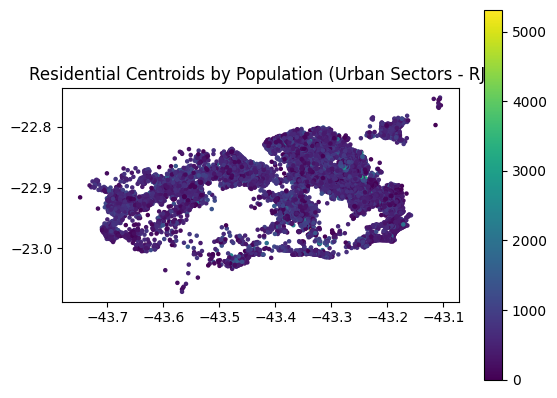

In [ ]:
# ========================
#  Install Dependencies
# ========================
# Run once if not installed
# pip install xlrd geopandas shapely pandas matplotlib openpyxl unidecode google-cloud-bigquery

# ========================
#  Residential Centroids
# ========================
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
from geobr import read_census_tract

# 1. Load population data (IBGE)
df_pop = pd.read_excel("C:\\Users\\kejsi\\Downloads\\Base_informacoes_setores2010_sinopse_RJ\\Base_informações_setores2010_sinopse_RJ\\Base_informações_setores2010_sinopse_RJ.xls")

# 2. Load sector geometries using geobr (only Rio de Janeiro municipality)


# Load census tracts for RJ state and filter by Rio's municipal code (3304557)
gdf_sectors = read_census_tract(code_tract=33, year=2010)
gdf_sectors = gdf_sectors[gdf_sectors['code_muni'] == 3304557].to_crs(epsg=4326)


# 3. Ensure geometries are valid (optional but recommended)
gdf_sectors = gdf_sectors[gdf_sectors.is_valid]

# 4. Compute metric centroids
gdf_sectors['id'] = gdf_sectors['code_tract'].astype(str)  # Replace with actual identifier

# Project to UTM zone 23S for Brazil (EPSG:31983)
gdf_metric = gdf_sectors.to_crs(epsg=31983)
gdf_metric['centroid_geom'] = gdf_metric.geometry.centroid

# Reproject centroids back to WGS84 and assign
gdf_sectors['centroid_geom'] = gdf_metric['centroid_geom'].to_crs(epsg=4326)


# 5. Prepare population data
df_pop['Cod_setor'] = df_pop['Cod_setor'].astype(str)

# 6. Merge geometry with census data
gdf_residential = gdf_sectors.merge(df_pop, left_on='id', right_on='Cod_setor', how='left')

# 7. Filter only urban sectors (1, 2, 3)
gdf_residential['Situacao_setor'] = pd.to_numeric(gdf_residential['Situacao_setor'], errors='coerce')
gdf_residential = gdf_residential[gdf_residential['Situacao_setor'].isin([1, 2, 3])]


# 8. Rename population variable to 'population'
gdf_residential = gdf_residential.rename(columns={'V014': 'population'})
gdf_residential = gdf_residential[gdf_residential['population'].notnull()]

# 9. Create centroid GeoDataFrame and reproject to WGS84 (EPSG:4326)
gdf_centroids = gpd.GeoDataFrame(
    gdf_residential[['id', 'population', 'centroid_geom']],
    geometry='centroid_geom',
    crs='EPSG:4326'  #  Correct CRS of the current geometry
)


# 10. Extract lat/lon for export
gdf_centroids['lon'] = gdf_centroids.geometry.x
gdf_centroids['lat'] = gdf_centroids.geometry.y

# 11. Export CSV
gdf_centroids.rename(columns={'id': 'setor_id'})[
    ['setor_id', 'population', 'lat', 'lon']
].to_csv("residential_centroids.csv", index=False)

# 12. Optional: plot
gdf_centroids.plot(column='population', markersize=5, cmap='viridis', legend=True)
plt.title("Residential Centroids by Population (Urban Sectors - RJ)")
plt.show()



# =======================
#  Employment Centroids
# =======================
from google.cloud import bigquery
from google.oauth2 import service_account
import unidecode

# 1. Authenticate BigQuery
key_path = "C:/Users/kejsi/Downloads/rais-455614-d00953360713.json"
credentials = service_account.Credentials.from_service_account_file(key_path)
project_id = "rais-455614"
client = bigquery.Client(credentials=credentials, project=project_id)

# 2. Query RAIS data
query = """
SELECT 
    ano,
    bairros_rj AS bairro,
    COUNTIF(vinculo_ativo_3112 = '1') AS total_vinculos_ativos,
    AVG(valor_remuneracao_media) AS media_salarial
FROM `basedosdados.br_me_rais.microdados_vinculos`
WHERE sigla_uf = 'RJ' 
    AND id_municipio = '3304557'
    AND ano = 2011
    AND bairros_rj IS NOT NULL
GROUP BY ano, bairro
ORDER BY ano, bairro;
"""
df = client.query(query).to_dataframe()

# 3. Load bairro shapefile
gdf_bairros = gpd.read_file("C:\\Users\\kejsi\\Downloads\\Limite_de_Bairros\\Limite_de_Bairros.shp").to_crs(epsg=4326)

# 4. Load bairro mapping
df_mapping = pd.read_excel("C:\\Users\\kejsi\\Downloads\\bairros_rj.xlsx")
df_mapping = df_mapping.rename(columns={'Nome': 'bairro_name_rais', 'Valor': 'rais_bairro_code'})
df['bairro'] = df['bairro'].astype(str)
df_mapping['rais_bairro_code'] = df_mapping['rais_bairro_code'].astype(str)

# 5. Merge RAIS bairro names
df = df.merge(df_mapping, how='left', left_on='bairro', right_on='rais_bairro_code')

# 6. Clean names
def clean_name(name):
    if pd.isna(name):
        return name
    name = unidecode.unidecode(name).lower().strip()
    for char in ['-', '/', '(', ')']:
        name = name.replace(char, ' ')
    return ' '.join(name.split())

df['bairro_name_rais'] = df['bairro_name_rais'].astype(str)
df['bairro_name_rais_clean'] = df['bairro_name_rais'].apply(clean_name)
gdf_bairros['nome_clean'] = gdf_bairros['nome'].apply(clean_name)

# 7. Manual corrections
manual_name_corrections = {
    'Araujo de Cosmos': 'cosmos',
    'Baia de Guanabara': 'galeao',
    'Nossa Senhora das Gracas': 'penha',
    'Curral Falso': 'guaratiba',
    'Dumas': 'cosmos',
    'Itacolomi': 'ilha de guaratiba',
    'Loteamento Madean': 'campo grande',
    'Tubiacanga': 'cacuia',
    'Dende': 'cacuia',
    'Guarabu': 'cacuia',
    'Freguesia - Ilha do Governador': 'freguesia ilha',
    'Freguesia - Jacarepagua': 'freguesia jacarepagua',
    'Oswaldo Cruz': 'osvaldo cruz',
}
df['bairro_name_rais'] = df['bairro_name_rais'].replace(manual_name_corrections)
df['bairro_name_rais_clean'] = df['bairro_name_rais'].apply(clean_name)

# 8. Merge with spatial data
gdf_employment_full = gdf_bairros.merge(df, how='left', left_on='nome_clean', right_on='bairro_name_rais_clean')

# 9. Project to a metric CRS for accurate centroid calculation
gdf_employment_full_metric = gdf_employment_full.to_crs(epsg=31983)  # UTM zone 23S (SIRGAS 2000)

# 10. Calculate true geometric centroids
gdf_employment_full_metric['centroid'] = gdf_employment_full_metric.geometry.centroid

# 11. Project centroids back to WGS84 (lat/lon)
gdf_centroids_latlon = gdf_employment_full_metric.set_geometry('centroid').to_crs(epsg=4326)

# 12. Extract lat/lon from projected centroids
gdf_employment_full['centroid_lat'] = gdf_centroids_latlon.geometry.y
gdf_employment_full['centroid_lon'] = gdf_centroids_latlon.geometry.x


#  Correct: all employment, no skill split, correct year
gdf_employment = gdf_employment_full[
    gdf_employment_full['ano'] == 2011
][['bairro_name_rais', 'centroid_lat', 'centroid_lon']]

# 11. Convert to GeoDataFrame
gdf_employment['geometry'] = gdf_employment.apply(lambda row: Point(row['centroid_lon'], row['centroid_lat']), axis=1)
gdf_employment = gpd.GeoDataFrame(gdf_employment, geometry='geometry', crs='EPSG:4326')

# 12. Export employment centroids
gdf_employment[['bairro_name_rais', 'centroid_lat', 'centroid_lon']].rename(
    columns={'bairro_name_rais': 'id', 'centroid_lat': 'lat', 'centroid_lon': 'lon'}
).to_csv("employment_centroids.csv", index=False)





newest version mesdite

In [ ]:
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx
import re
from joblib import Parallel, delayed, parallel_backend
import multiprocessing

# ------------------------------------------------------
# 1. Load multimodal graph
# ------------------------------------------------------
Gfinal = G_combined  # ← Make sure G_combined is already defined

# ------------------------------------------------------
# 2. Clean and normalize travel_time values
# ------------------------------------------------------

def parse_travel_time(val):
    if isinstance(val, (int, float)):
        return float(val)
    elif isinstance(val, str):
        val = val.strip()
        match = re.match(r'^([\d.]+),(\d+)$', val)
        if match:
            int_part = match.group(1).replace('.', '')
            dec_part = match.group(2)
            try:
                return float(f"{int_part}.{dec_part}")
            except ValueError:
                return None
        else:
            try:
                return float(val.replace(',', '.'))
            except ValueError:
                return None
    else:
        return None

def clean_travel_times(graph, min_minutes=1, max_minutes=240):
    removed_edges = 0
    kept_edges = 0

    for u, v, data in list(graph.edges(data=True)):
        raw_val = data.get("travel_time")
        travel_minutes = parse_travel_time(raw_val)

        if travel_minutes is None or not (min_minutes <= travel_minutes <= max_minutes):
            graph.remove_edge(u, v)
            removed_edges += 1
        else:
            data["travel_time"] = travel_minutes
            kept_edges += 1

    print(f" Cleaned travel times:")
    print(f"    Removed {removed_edges:,} bad edges")
    print(f"    Kept {kept_edges:,} valid edges")
    return graph

Gfinal = clean_travel_times(Gfinal)

# Check basic stats
all_weights = [data['travel_time'] for _, _, data in Gfinal.edges(data=True)]
print(f" Travel time stats: Min={min(all_weights):.2f} | Max={max(all_weights):.2f} | Mean={sum(all_weights)/len(all_weights):.2f}")
print("Sample travel_time values from graph (raw):", all_weights[:10])


# ------------------------------------------------------
# 3. Snap residential and employment centroids
# ------------------------------------------------------

gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

print(" Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print(" Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())


# ------------------------------------------------------
# 4. Compute Dijkstra OD Matrix in Parallel (With ETA)
# ------------------------------------------------------

res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()
input_data = list(res_id_to_node.items())

num_cores = max(1, multiprocessing.cpu_count() // 2)
print(f" Using {num_cores} cores (threading backend) for parallel Dijkstra")

chunk_size = 100
chunks = [input_data[i:i + chunk_size] for i in range(0, len(input_data), chunk_size)]

def compute_batch(batch):
    results = []
    for res_id, res_node in batch:
        try:
            lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
            results.extend([
                (res_id, emp_id, lengths[emp_node])
                for emp_id, emp_node in emp_id_to_node.items()
                if emp_node in lengths
            ])
        except Exception as e:
            print(f" Error at res_id={res_id}: {e}")
    return results

flat_results = []
with parallel_backend("threading", n_jobs=num_cores):
    for i, batch_result in enumerate(tqdm(
        Parallel()(delayed(compute_batch)(chunk) for chunk in chunks),
        total=len(chunks),
        desc=" Safe Parallel Dijkstra (Batched)",
        unit="batch"
    )):
        flat_results.extend(batch_result)


# ------------------------------------------------------
# 5. Save OD Travel Time Matrix to CSV
# ------------------------------------------------------

travel_time_df = pd.DataFrame(flat_results, columns=['res_id', 'emp_id', 'travel_time'])
travel_time_df.to_csv("tau_ij_post_expansionnew.csv", index=False)

print(" Travel times computed and saved to 'tau_ij_post_expansion_FINAL.csv'")


✅ Cleaned travel times:
   ➤ Removed 0 bad edges
   ➤ Kept 984,756 valid edges
🧪 Travel time stats: Min=1.00 | Max=237.21 | Mean=6.11
Sample travel_time values from graph (raw): [1.276111111111111, 1.2066666666666668, 2.91784607092774, 2.3883778964036706, 1.685358644121327, 4.882664408249016, 3.9552731094889753, 4.052075926068292, 1.776725329730774, 5.834802927691664]
📍 Unsnapped residential: 0
📍 Unsnapped employment: 0
🧠 Using 4 cores (threading backend) for parallel Dijkstra


⚡ Safe Parallel Dijkstra (Batched): 100%|██████████| 103/103 [00:00<00:00, 131.16batch/s]


✅ Travel times computed and saved to 'tau_ij_post_expansion_FINAL.csv'


In [ ]:
long_edges = sorted([(u, v, d['travel_time']) for u, v, d in Gfinal.edges(data=True)], key=lambda x: -x[2])
print(" Top 10 longest edges:")
for u, v, wt in long_edges[:10]:
    print(f"{u} → {v} = {wt:.2f} min")


🚨 Top 10 longest edges:
drive_4481756114 → drive_4481756029 = 237.21 min
drive_4481756029 → drive_4481756114 = 237.21 min
walk_5095445545 → walk_5095409618 = 235.57 min
walk_5095409618 → walk_5095445545 = 235.57 min
drive_3423425569 → drive_2960373056 = 233.82 min
drive_2960373056 → drive_3423425569 = 233.82 min
drive_3068177367 → drive_3068178859 = 233.57 min
drive_3068178859 → drive_3068177367 = 233.57 min
walk_4008013565 → walk_4638364139 = 232.86 min
walk_4638364139 → walk_4008013565 = 232.86 min


Version 2 (investigating the weird travel times)

In [ ]:
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx
import re
from joblib import Parallel, delayed, parallel_backend
import multiprocessing

# ------------------------------------------------------
# 1. Load multimodal graph
# ------------------------------------------------------
Gfinal = G_combined  #  Make sure G_combined is already defined


# ------------------------------------------------------
# 2. Clean and normalize travel_time values
# ------------------------------------------------------

def parse_travel_time(val):
    if isinstance(val, (int, float)):
        raw_seconds = float(val)
    elif isinstance(val, str):
        val = val.strip()
        match = re.match(r'^([\d.]+),(\d+)$', val)
        if match:
            int_part = match.group(1).replace('.', '')
            dec_part = match.group(2)
            try:
                raw_seconds = float(f"{int_part}.{dec_part}")
            except ValueError:
                return None
        else:
            try:
                raw_seconds = float(val.replace(',', '.'))
            except ValueError:
                return None
    else:
        return None

    return raw_seconds / 60.0  # Convert to minutes

def clean_travel_times(graph, min_minutes=1, max_minutes=240):
    removed_edges = 0
    kept_edges = 0

    for u, v, data in list(graph.edges(data=True)):
        raw_val = data.get("travel_time")
        travel_minutes = parse_travel_time(raw_val)

        if travel_minutes is None or not (min_minutes <= travel_minutes <= max_minutes):
            graph.remove_edge(u, v)
            removed_edges += 1
        else:
            data["travel_time"] = travel_minutes
            kept_edges += 1

    print(f" Cleaned travel times:")
    print(f"    Removed {removed_edges:,} bad edges")
    print(f"    Kept {kept_edges:,} valid edges")
    return graph

Gfinal = clean_travel_times(Gfinal)

# Check basic stats
all_weights = [data['travel_time'] for _, _, data in Gfinal.edges(data=True)]
print(f" Travel time stats: Min={min(all_weights):.2f} | Max={max(all_weights):.2f} | Mean={sum(all_weights)/len(all_weights):.2f}")


# ------------------------------------------------------
# 3. Snap residential and employment centroids
# ------------------------------------------------------

gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

print(" Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print(" Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())


# ------------------------------------------------------
# 4. Compute Dijkstra OD Matrix in Parallel (Safe Version)
# ------------------------------------------------------

res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()
input_data = list(res_id_to_node.items())

# Use a conservative number of cores
num_cores = max(1, multiprocessing.cpu_count() // 2)
print(f" Using {num_cores} cores (threading backend) for parallel Dijkstra")

# Split input into manageable batches
chunk_size = 100
chunks = [input_data[i:i + chunk_size] for i in range(0, len(input_data), chunk_size)]

def compute_batch(batch):
    results = []
    for res_id, res_node in batch:
        try:
            lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
            results.extend([
                (res_id, emp_id, lengths[emp_node])
                for emp_id, emp_node in emp_id_to_node.items()
                if emp_node in lengths
            ])
        except Exception as e:
            print(f" Error at res_id={res_id}: {e}")
    return results

# Run with threading backend for Windows stability
flat_results = []
with parallel_backend("threading", n_jobs=num_cores):
    for batch_result in tqdm(
        Parallel()(delayed(compute_batch)(chunk) for chunk in chunks),
        total=len(chunks),
        desc=" Safe Parallel Dijkstra (Batched)"
    ):
        flat_results.extend(batch_result)


# ------------------------------------------------------
# 5. Save OD Travel Time Matrix to CSV
# ------------------------------------------------------

travel_time_df = pd.DataFrame(flat_results, columns=['res_id', 'emp_id', 'travel_time'])
travel_time_df.to_csv("tau_ij_post_expansionnew.csv", index=False)

print(" Travel times computed and saved to 'tau_ij_post_expansionnew.csv'")


In [ ]:
sample_vals = [data['travel_time'] for _, _, data in Gfinal.edges(data=True)]
print("Sample travel_time values from graph (raw):", sample_vals[:10])


Sample travel_time values from graph (raw): [1.276111111111111, 1.2066666666666668, 2.91784607092774, 2.3883778964036706, 1.685358644121327, 4.882664408249016, 3.9552731094889753, 4.052075926068292, 1.776725329730774, 5.834802927691664]


Diagnostic cell

In [ ]:
for prefix, graph in [('walk_', G_walk), ('drive_', G_drive), ('gtfs_', G_transit), ('subvlt_', G_subway_vlt)]:
    missing = [n for n, d in graph.nodes(data=True) if 'pos' not in d]
    print(f"{prefix}: {len(missing)} nodes missing 'pos'")


In [ ]:
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx

# ------------------------------------------------------
# 1. Use the final multimodal graph
# ------------------------------------------------------
Gfinal = G_combined  # Make sure this is correctly defined

# ------------------------------------------------------
# 🔧 Clean travel_time weights (European format fix)
# ------------------------------------------------------
def clean_travel_times(graph):
    for u, v, data in graph.edges(data=True):
        val = data.get("travel_time")
        if isinstance(val, str):
            try:
                # Convert strings like "12.388.945,385" → 12388945.385
                data["travel_time"] = float(val.replace('.', '').replace(',', '.'))
            except Exception:
                data["travel_time"] = float('inf')  # Optional fallback
    return graph

Gfinal = clean_travel_times(Gfinal)  #  Apply cleaning before using Dijkstra



# Check a sample of travel_time values before computing
sample_weights = [
    data['travel_time']
    for _, _, data in list(Gfinal.edges(data=True))[:5000]  # sample first 5000 edges (adjust as needed)
    if isinstance(data.get('travel_time'), (int, float))
]

if sample_weights:
    print(f"Sample travel_time stats:")
    print(f"Min: {min(sample_weights):,.2f}")
    print(f"Max: {max(sample_weights):,.2f}")
    print(f"Mean: {sum(sample_weights)/len(sample_weights):,.2f}")
    print(f"Sample (first 10): {sample_weights[:10]}")
else:
    print(" No valid numeric travel_time values found.")









# ------------------------------------------------------
# 2. Snap centroids to nearest graph nodes
# ------------------------------------------------------
# Ensure centroids are in EPSG:4326
gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

# Build a dictionary of only valid nodes with 'pos'
valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}

# Create geometry list and spatial index
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)

# Use WKT for reliable key matching
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

# Snap residential and employment centroids
gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

# Optional check: print number of centroids that failed to snap (should be 0)
print("Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print("Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())

# ------------------------------------------------------
# 3. Dijkstra OD Matrix on travel_time (Serial + Long Form)
# ------------------------------------------------------
# Build dictionaries mapping index → nearest node ID
res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()

# Define function to run Dijkstra for one origin
def compute_dijkstra(res_id_and_node):
    res_id, res_node = res_id_and_node
    try:
        lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
        return [
            (res_id, emp_id, lengths[emp_node])
            for emp_id, emp_node in emp_id_to_node.items()
            if emp_node in lengths
        ]
    except Exception as e:
        print(f" Error at {res_id}: {e}")
        return []

# Prepare input data
input_data = list(res_id_to_node.items())
results = []

# Run serially (no multiprocessing)
for item in tqdm(input_data, desc="Serial Dijkstra"):
    results.extend(compute_dijkstra(item))

# Convert to long-form DataFrame
travel_time_df = pd.DataFrame(results, columns=['res_id', 'emp_id', 'travel_time'])

# Save result
travel_time_df.to_csv("tau_ij_post_expansion.csv", index=False)


Third option

In [ ]:
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx

# ------------------------------------------------------
# 1. Use the final multimodal graph
# ------------------------------------------------------
Gfinal = G_combined  # ← Ensure G_combined is defined

# ------------------------------------------------------
# 🔧 Clean and validate travel_time weights
# ------------------------------------------------------
def clean_travel_times(graph, max_reasonable_minutes=1440):  # 1440 min = 1 day
    removed_edges = []
    for u, v, data in graph.edges(data=True):
        val = data.get("travel_time")
        cleaned_val = None
        if isinstance(val, str):
            try:
                # Convert formats like "12.388.945,385" → 12388945.385
                cleaned_val = float(val.replace('.', '').replace(',', '.'))
            except Exception:
                pass
        elif isinstance(val, (int, float)):
            cleaned_val = val

        if cleaned_val is None or cleaned_val <= 0 or cleaned_val > max_reasonable_minutes:
            removed_edges.append((u, v))
        else:
            data["travel_time"] = cleaned_val

    graph.remove_edges_from(removed_edges)
    print(f" Cleaned travel_time: Removed {len(removed_edges):,} bad edges")
    return graph

Gfinal = clean_travel_times(Gfinal)

#  Check final travel_time values
all_weights = [
    data['travel_time']
    for _, _, data in Gfinal.edges(data=True)
    if isinstance(data.get('travel_time'), (int, float))
]

if not all_weights:
    raise ValueError(" No valid numeric travel_time values found. Aborting.")

print(f"Sample travel_time stats:")
print(f"Min: {min(all_weights):,.2f}")
print(f"Max: {max(all_weights):,.2f}")
print(f"Mean: {sum(all_weights)/len(all_weights):,.2f}")
print(f"Sample (first 10): {all_weights[:10]}")

# ------------------------------------------------------
# 2. Snap centroids to nearest graph nodes
# ------------------------------------------------------
gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

print("Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print("Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())

# ------------------------------------------------------
# 3. Dijkstra OD Matrix on travel_time (Serial + Long Form)
# ------------------------------------------------------
res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()

def compute_dijkstra(res_id_and_node):
    res_id, res_node = res_id_and_node
    try:
        lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
        return [
            (res_id, emp_id, lengths[emp_node])
            for emp_id, emp_node in emp_id_to_node.items()
            if emp_node in lengths
        ]
    except Exception as e:
        print(f" Error at {res_id}: {e}")
        return []

input_data = list(res_id_to_node.items())
results = []

for item in tqdm(input_data, desc="Serial Dijkstra"):
    results.extend(compute_dijkstra(item))

travel_time_df = pd.DataFrame(results, columns=['res_id', 'emp_id', 'travel_time'])
travel_time_df.to_csv("tau_ij_post_expansion.csv", index=False)


In [ ]:
all_weights = [
    data['travel_time']
    for _, _, data in Gfinal.edges(data=True)
    if isinstance(data.get('travel_time'), (int, float))
]

print(sorted(all_weights, reverse=True)[:20])


Parallel Processing

In [ ]:
import pandas as pd
from tqdm.notebook import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx
import multiprocessing as mp

# ----------------------------------------------------------------
# 1. Load and clean graph (replace G_combined with your actual graph)
# ----------------------------------------------------------------
Gfinal = G_combined  #  This must be already created in your notebook above

# Clean travel_time edge weights
def clean_travel_times(graph):
    for u, v, data in graph.edges(data=True):
        val = data.get("travel_time")
        if isinstance(val, str):
            try:
                # Convert strings like "12.388.945,385" → 12388945.385
                data["travel_time"] = float(val.replace('.', '').replace(',', '.'))
            except Exception:
                data["travel_time"] = float('inf')  # fallback
    return graph

Gfinal = clean_travel_times(Gfinal)

# ----------------------------------------------------------------
# 2. Snap centroids to nearest graph nodes
# ----------------------------------------------------------------
# Replace these with your actual GeoDataFrames
# gdf_residential and gdf_employment should be already defined
gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

# Build node → Point mapping
valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

# Apply snapping
gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

# Sanity check
print("Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print("Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())

# Build dictionaries
res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()

# --- Dijkstra function ---
def compute_dijkstra(res_id_and_node):
    res_id, res_node = res_id_and_node
    try:
        lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
        return [
            (res_id, emp_id, lengths[emp_node])
            for emp_id, emp_node in emp_id_to_node.items()
            if emp_node in lengths
        ]
    except Exception as e:
        print(f" Error at {res_id}: {e}")
        return []

In [ ]:
# Must be in its own cell on Windows
input_data = list(res_id_to_node.items())
results = []

with mp.Pool(processes=mp.cpu_count() - 1) as pool:
    for partial in tqdm(pool.imap_unordered(compute_dijkstra, input_data), total=len(input_data), desc="Parallel Dijkstra"):
        results.extend(partial)

travel_time_df = pd.DataFrame(results, columns=['res_id', 'emp_id', 'travel_time'])
travel_time_df.to_csv("tau_ij_post_expansion_parallel.csv", index=False)
travel_time_df.head()


Original - Issue Travel times


In [ ]:
# OG ONE 
import pandas as pd
from tqdm import tqdm
from shapely.geometry import Point
from shapely.strtree import STRtree
import networkx as nx

# ------------------------------------------------------
# 1. Use the final multimodal graph
# ------------------------------------------------------
Gfinal = G_combined  #  Make sure this is correctly defined

# ------------------------------------------------------
# 2. Snap centroids to nearest graph nodes
# ------------------------------------------------------
# Ensure centroids are in EPSG:4326
gdf_res_proj = gdf_residential.to_crs("EPSG:4326")
gdf_emp_proj = gdf_employment.to_crs("EPSG:4326")

# Build a dictionary of only valid nodes with 'pos'
valid_nodes = {n: Point(data['pos']) for n, data in Gfinal.nodes(data=True) if 'pos' in data}

# Create geometry list and spatial index
node_points = list(valid_nodes.values())
spatial_index = STRtree(node_points)

# Use WKT for reliable key matching
geom_to_node = {geom.wkt: node_id for node_id, geom in zip(valid_nodes.keys(), node_points)}

def snap_to_nearest(pt):
    nearest_idx = spatial_index.nearest(pt)
    nearest_geom = node_points[nearest_idx]
    return geom_to_node[nearest_geom.wkt]

# Snap residential and employment centroids
gdf_res_proj['nearest_node'] = gdf_res_proj.geometry.apply(snap_to_nearest)
gdf_emp_proj['nearest_node'] = gdf_emp_proj.geometry.apply(snap_to_nearest)

# Optional check: print number of centroids that failed to snap (should be 0)
print("Unsnapped residential:", gdf_res_proj['nearest_node'].isna().sum())
print("Unsnapped employment:", gdf_emp_proj['nearest_node'].isna().sum())

# ------------------------------------------------------
# 3. Dijkstra OD Matrix on travel_time (Serial + Long Form)
# ------------------------------------------------------
# Build dictionaries mapping index → nearest node ID
res_id_to_node = gdf_res_proj['nearest_node'].to_dict()
emp_id_to_node = gdf_emp_proj['nearest_node'].to_dict()

# Define function to run Dijkstra for one origin
def compute_dijkstra(res_id_and_node):
    res_id, res_node = res_id_and_node
    try:
        lengths = nx.single_source_dijkstra_path_length(Gfinal, res_node, weight='travel_time')
        return [
            (res_id, emp_id, lengths[emp_node])
            for emp_id, emp_node in emp_id_to_node.items()
            if emp_node in lengths
        ]
    except Exception as e:
        print(f" Error at {res_id}: {e}")
        return []

# Prepare input data
input_data = list(res_id_to_node.items())
results = []

# Run serially (no multiprocessing)
for item in tqdm(input_data, desc="Serial Dijkstra"):
    results.extend(compute_dijkstra(item))

# Convert to long-form DataFrame
travel_time_df = pd.DataFrame(results, columns=['res_id', 'emp_id', 'travel_time'])

# Save result
travel_time_df.to_csv("tau_ij_post_expansion.csv", index=False)
